<a href="https://colab.research.google.com/github/aragornchunletia/Ray_Tracer/blob/main/Results_final_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer , recall_score , f1_score , matthews_corrcoef ,auc ,roc_curve , precision_score
import matplotlib.pyplot as plt

In [3]:
training_data = pd.read_csv("/content/drive/MyDrive/RIL_POP_MODEL/training_set.csv")
evaluation_data = pd.read_csv("/content/drive/MyDrive/RIL_POP_MODEL/testing_dataset.csv")


In [4]:
switching_1s_to_0s = training_data.Y.map(lambda x : 0 if x == 1 else 1 )

I have switched 1's to 0's and vice-versa, as the scoring is done on the positives on the scoring functions and making the code readable, as an additional argument is needed to be added to the scoring functions for the label 0.

In [5]:
training_data['Y'] = switching_1s_to_0s

In [6]:
training_data.Y.value_counts()

,count
Y,
0,217
1,26


In [8]:
X_train,X_test,Y_train,Y_test = train_test_split(training_data.drop(["RIL" , "Y"] , axis = 1) , training_data.Y , stratify=training_data.Y , random_state = 42)


In [10]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Through multiple experiments, using a 5-fold cross validation across different Weak classifiers we have discoverd that, KNN and Decision Trees are performing best on multiple scoring metrics (F1 , Precision , Mathews Correlation Coeff) for the provided Dataset.
```
Results for LogisticRegression:
f1: 0.1333
precision: 0.2000
mcc: 0.1270


Results for KNearest:
f1: 0.7611
precision: 0.9100
mcc: 0.7693


Results for Support Vector Classifier:
f1: 0.0800
precision: 0.2000
mcc: 0.0957


Results for DecisionTreeClassifier:
f1: 0.7388
precision: 0.7343
mcc: 0.7176

```

But this should not come as a surprise to us that KNN is the best performing model for this Dataset as in an N-dimensional space if are searching for similiar datapoints then they are bound to be in each others vicinity.Hence Intution and Experiment allign for this Process.

Grid Search across the below parameters:


    "n_neighbors": list(range(2, 11, 1)),
    "weights": ['uniform', 'distance'],
    "algorithm": ['auto', 'ball_tree', 'kd_tree', 'brute'],
    "leaf_size": list(range(20, 50, 10)),
    "p": [1, 2]  # Minkowski distance metric (1=Manhattan, 2=Euclidean)


Provided us with the best Hyper parameters for our model which were:
  ```
  'algorithm': 'auto',
  'leaf_size': 20,
  'n_neighbors': 6,
  'p': 1,
  'weights': 'distance'
  ```
  Algo:auto
  

*  *The algorithm parameter was set to 'auto', allowing the K-NearestNeighbors classifier to automatically select the most suitable algorithm for finding the nearest neighbors based on the dataset. This dynamic selection enhances computational efficiency.*  

leaf_size: 20

* *The leaf_size was set to 20, balancing between computational efficiency and model accuracy in tree-based algorithms. Leaf size influences the depth of the tree structure and consequently the performance of neighbor searches. Larger the leaf size the more the accuracy but it also tends to overfit the data too hence resulting in a weaker result on unseen data.*

n_neighbors: 6
* *n_neighbors tells us about the number of datapoints that influnce the classification of a datapoint. It is set to 6 being and again we can justify it logically and intutively as are data is heavyily imbalanced and if we try would try more number of neighbours then the we would be moving towards miss-classification.*


p: 1


* *p = 1 uses the **Manhattan distance** metric to compute the distance between data points. It is defined as the sum of the absolute differences between their corresponding feature values.*
* *For two points*
  * *$ \mathbf{x} = (x_1, x_2, \dots, x_n) $*
  * *$ \mathbf{y} = (y_1, y_2, \dots, y_n) $*
* *The Manhattan distance $ d(\mathbf{x}, \mathbf{y}) $ is given by the formula:*
  * *$ d(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^{n} |x_i - y_i| $*
* *This distance metric emphasizes the absolute differences in feature values, capturing variations linearly across all dimensions.*

weights: distance

* *The weights parameter was set to 'distance', which assigns greater influence to closer neighbors during classification. This method prioritizes proximity, ensuring that nearer data points have a stronger impact on the final classification result.*








In [11]:
kparams = {'algorithm': 'auto', 'leaf_size': 20, 'n_neighbors': 6, 'p': 1, 'weights': 'distance'}
knn_clf = KNeighborsClassifier(**kparams)
knn_clf.fit(X_train,Y_train)

KNeighborsClassifier(leaf_size=20, n_neighbors=6, p=1, weights='distance')

In [12]:
clf_probabs = knn_clf.predict_proba(X_test)

We are using Youden's J statistic as a measure to evaluate the performance of the binary classifier. It balances the trade-off between sensitivity (true positive rate) and specificity (true negative rate), providing a single metric to assess the model’s ability to differentiate between the positive and negative classes.
The J statistic is calculated as:<br>
$𝐽=Sensitivity+Specificity−1$<br>
A J value close to 1 indicates that the classifier performs well in correctly identifying both positive and negative cases, while a value close to 0 suggests performance near random chance. Negative values indicate a classifier performing worse than random.

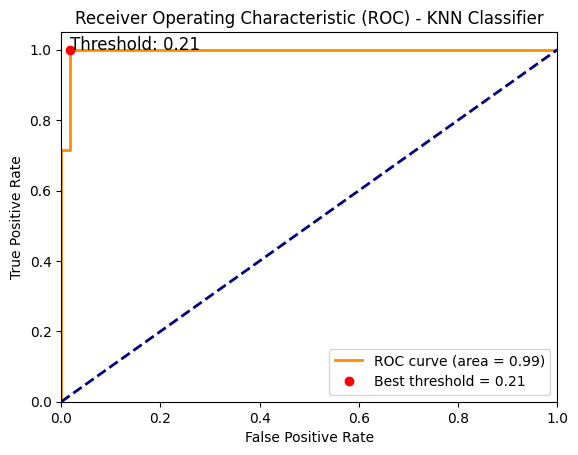

In [14]:
y_scores = clf_probabs[:, 1]

fpr, tpr, thresholds = roc_curve(Y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Youden's J statistic to find the best threshold
j_scores = tpr - fpr
best_threshold_index = np.argmax(j_scores)
best_threshold = thresholds[best_threshold_index]


plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

plt.plot(fpr[best_threshold_index], tpr[best_threshold_index], 'ro', label=f'Best threshold = {best_threshold:.2f}')
plt.text(fpr[best_threshold_index], tpr[best_threshold_index], f'Threshold: {best_threshold:.2f}', fontsize=12)


plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - KNN Classifier')
plt.legend(loc="lower right")
plt.show()

<h2>Scoring Metrics</h2>

Scoring Metrics for a classification task are different than the scoring metrics for a floating number(Regression like tasks where we predict values rather than classify them).<br>
Lets walk through an example why accuracy is not a good metric for classification:
Lets Assume, we have a classification task at hand diffrentiating **erasers(X1)** with **sharpners(X2)**.<br>
$X1 = 90 , Y = 0$<br>
$X2 = 10 , Y = 1$<br>
if our model *M* predicts all $0's $ for all $100$ data points, still it would have an accuracy of $0.9$ as it is classifying all sharpners as erasers.<br>
Hence we have confusion matrix based evaluation for clasification based tasks.<br>
<h2>Confusion Matrix</h2>
<table border="1" cellpadding="10" cellspacing="0">
  <thead>
    <tr>
      <th></th>
      <th>Predicted Positive</th>
      <th>Predicted Negative</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Actual Positive</td>
      <td>TP (True Positive)</td>
      <td>FN (False Negative)</td>
    </tr>
    <tr>
      <td>Actual Negative</td>
      <td>FP (False Positive)</td>
      <td>TN (True Negative)</td>
    </tr>
  </tbody>
</table>

* **TP** : Instances where model predicted positive and actual value was positive.
* **FN** : Instances where model predicted negative but actual value was positive.

* **FP** : Instances where model predicted positive but actual value was negative.

* **TN** : Instances where model predicted negative and the value was neagtive.

The metrics we used for model are:

1. Precision: $\frac{TP}{TP+FP}$<br><br>
2. F1 = $ \frac{2}{precision^{-1} + recall{^-1}}$<br><br>
3. Matthews correlation coefficient: $
\frac{(TP \times TN - FP \times FN)}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$<br><br>

MCC is a very good metric to judge a model which is trained on a imbalanced set our dataset is to highly imbalanced with $1:10$ class ratio as it takes all four quadrants of an confusion matrix to calculate the score it varies from $\{-1, 1\}$ where $0$ making it random guessuer as its close to 1 the better the model is performing .





In [13]:
def get_scores(probabs , threshold):
  y_predict = (probabs[:,1] >= threshold).astype(int)
  precision = precision_score(Y_test , y_predict)
  f1 = f1_score(Y_test , y_predict)
  mcc = matthews_corrcoef(Y_test , y_predict)
  print(f"Threshold: {threshold:.2f}")
  print(f"Precision: {precision:.4f} , F1-Score: {f1:.4f}, Mcc: {mcc:.4f}")
  print("-" * 50)

In [16]:
get_scores(clf_probabs , 0.21)

Threshold: 0.21
Precision: 0.8750 , F1-Score: 0.9333, Mcc: 0.9267
--------------------------------------------------


From above results we can see we have a very good performing model. Mcc score is around $0.92$ which is great for an imbalanced classifiacation process, Now we would train our model on the complete dataset and then use it classify the the f2 population.

In [18]:
X , Y = training_data.drop(["RIL" , "Y"] , axis = 1) , training_data.Y
min_max_scaler = MinMaxScaler()
X , Y = min_max_scaler.fit_transform(X) , Y
X_eval = min_max_scaler.transform(evaluation_data.drop('RIL' , axis = 1))
eval_names = evaluation_data.RIL.to_list()

In [19]:
params = {'algorithm': 'auto', 'leaf_size': 20, 'n_neighbors': 6, 'p': 1, 'weights': 'distance'}
clf = KNeighborsClassifier(**kparams)

In [21]:
clf.fit(X,Y)

KNeighborsClassifier(leaf_size=20, n_neighbors=6, p=1, weights='distance')

In [22]:
eval_predict_probabs = clf.predict_proba(X_eval)
eval_predict = (eval_predict_probabs[:,1] >= 0.21).astype(int)


In [23]:
def get_eval_df(names,predictions):
  selected_RIL = [name for name , prediction in zip(names , predictions) if prediction == 1]
  df = evaluation_data[evaluation_data.RIL.isin(selected_RIL)]
  return df

In [24]:
selected_f2 = get_eval_df(eval_names , eval_predict)

<table>
<thead>
<tr><th style="text-align: right;">  </th><th>RIL             </th><th style="text-align: right;">  day0</th><th style="text-align: right;">    day3</th><th style="text-align: right;">   day6</th><th style="text-align: right;">   day9</th><th style="text-align: right;">  day12</th><th style="text-align: right;">  day15</th><th style="text-align: right;">  day18</th><th style="text-align: right;">  day21</th><th style="text-align: right;">  day24</th><th style="text-align: right;">   day27</th><th style="text-align: right;">   day30</th><th style="text-align: right;">   day33</th><th style="text-align: right;">   day36</th><th style="text-align: right;">   day39</th><th style="text-align: right;">  day42</th><th style="text-align: right;">  day45</th><th style="text-align: right;">  day48</th></tr>
</thead>
<tbody>
<tr><td style="text-align: right;"> 3</td><td>F2_2_S24        </td><td style="text-align: right;">     0</td><td style="text-align: right;">40      </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;"> 70     </td><td style="text-align: right;"> 70     </td><td style="text-align: right;"> 70     </td><td style="text-align: right;"> 80     </td><td style="text-align: right;">     80</td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td></tr>
<tr><td style="text-align: right;"> 5</td><td>F2_4_S24        </td><td style="text-align: right;">     0</td><td style="text-align: right;">33.3333 </td><td style="text-align: right;">33.3333</td><td style="text-align: right;">33.3333</td><td style="text-align: right;">33.3333</td><td style="text-align: right;">33.3333</td><td style="text-align: right;">33.3333</td><td style="text-align: right;">33.3333</td><td style="text-align: right;">33.3333</td><td style="text-align: right;"> 33.3333</td><td style="text-align: right;"> 33.3333</td><td style="text-align: right;"> 33.3333</td><td style="text-align: right;"> 33.3333</td><td style="text-align: right;"> 33.3333</td><td style="text-align: right;">     50</td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td></tr>
<tr><td style="text-align: right;"> 7</td><td>F2_6_S24        </td><td style="text-align: right;">     0</td><td style="text-align: right;">40      </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;"> 50     </td><td style="text-align: right;"> 50     </td><td style="text-align: right;"> 50     </td><td style="text-align: right;"> 50     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;">     70</td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td></tr>
<tr><td style="text-align: right;"> 8</td><td>F2_7_S24        </td><td style="text-align: right;">     0</td><td style="text-align: right;"> 0      </td><td style="text-align: right;"> 0     </td><td style="text-align: right;"> 0     </td><td style="text-align: right;">20     </td><td style="text-align: right;">20     </td><td style="text-align: right;">20     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;"> 40     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td></tr>
<tr><td style="text-align: right;">11</td><td>F2_10_S24       </td><td style="text-align: right;">     0</td><td style="text-align: right;">60      </td><td style="text-align: right;">60     </td><td style="text-align: right;">60     </td><td style="text-align: right;">60     </td><td style="text-align: right;">60     </td><td style="text-align: right;">60     </td><td style="text-align: right;">60     </td><td style="text-align: right;">60     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;">100     </td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td></tr>
<tr><td style="text-align: right;">14</td><td>F2_13_S24       </td><td style="text-align: right;">     0</td><td style="text-align: right;">30      </td><td style="text-align: right;">30     </td><td style="text-align: right;">30     </td><td style="text-align: right;">30     </td><td style="text-align: right;">30     </td><td style="text-align: right;">30     </td><td style="text-align: right;">30     </td><td style="text-align: right;">30     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;"> 70     </td><td style="text-align: right;"> 80     </td><td style="text-align: right;"> 80     </td><td style="text-align: right;"> 90     </td><td style="text-align: right;">     90</td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td></tr>
<tr><td style="text-align: right;">16</td><td>F2_15_S24       </td><td style="text-align: right;">     0</td><td style="text-align: right;">10      </td><td style="text-align: right;">20     </td><td style="text-align: right;">20     </td><td style="text-align: right;">20     </td><td style="text-align: right;">20     </td><td style="text-align: right;">20     </td><td style="text-align: right;">20     </td><td style="text-align: right;">30     </td><td style="text-align: right;"> 40     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;"> 90     </td><td style="text-align: right;">     90</td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td></tr>
<tr><td style="text-align: right;">17</td><td>F2_16_S24       </td><td style="text-align: right;">     0</td><td style="text-align: right;">50      </td><td style="text-align: right;">60     </td><td style="text-align: right;">60     </td><td style="text-align: right;">60     </td><td style="text-align: right;">60     </td><td style="text-align: right;">60     </td><td style="text-align: right;">60     </td><td style="text-align: right;">60     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;"> 70     </td><td style="text-align: right;"> 80     </td><td style="text-align: right;">     80</td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td></tr>
<tr><td style="text-align: right;">18</td><td>F2_17_S24       </td><td style="text-align: right;">     0</td><td style="text-align: right;">40      </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;"> 60     </td><td style="text-align: right;">     60</td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td></tr>
<tr><td style="text-align: right;">25</td><td>F2_24_S24       </td><td style="text-align: right;">     0</td><td style="text-align: right;">40      </td><td style="text-align: right;">50     </td><td style="text-align: right;">50     </td><td style="text-align: right;">50     </td><td style="text-align: right;">60     </td><td style="text-align: right;">80     </td><td style="text-align: right;">80     </td><td style="text-align: right;">80     </td><td style="text-align: right;"> 80     </td><td style="text-align: right;"> 80     </td><td style="text-align: right;"> 80     </td><td style="text-align: right;"> 80     </td><td style="text-align: right;"> 80     </td><td style="text-align: right;">     80</td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td></tr>
<tr><td style="text-align: right;">30</td><td>RIL_110_S23     </td><td style="text-align: right;">     0</td><td style="text-align: right;"> 9.09091</td><td style="text-align: right;">27.2727</td><td style="text-align: right;">27.2727</td><td style="text-align: right;">27.2727</td><td style="text-align: right;">27.2727</td><td style="text-align: right;">27.2727</td><td style="text-align: right;">27.2727</td><td style="text-align: right;">50     </td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td></tr>
<tr><td style="text-align: right;">31</td><td>TG_88_S23       </td><td style="text-align: right;">     0</td><td style="text-align: right;">42.8571 </td><td style="text-align: right;">42.8571</td><td style="text-align: right;">42.8571</td><td style="text-align: right;">42.8571</td><td style="text-align: right;">42.8571</td><td style="text-align: right;">57.1429</td><td style="text-align: right;">57.1429</td><td style="text-align: right;">57.1429</td><td style="text-align: right;"> 57.1429</td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td></tr>
<tr><td style="text-align: right;">55</td><td>F2_11088-3-8_S23</td><td style="text-align: right;">     0</td><td style="text-align: right;">20      </td><td style="text-align: right;">30     </td><td style="text-align: right;">30     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;">40     </td><td style="text-align: right;"> 40     </td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td></tr>
<tr><td style="text-align: right;">70</td><td>RIL_110         </td><td style="text-align: right;">     0</td><td style="text-align: right;"> 9.09091</td><td style="text-align: right;">27.2727</td><td style="text-align: right;">27.2727</td><td style="text-align: right;">27.2727</td><td style="text-align: right;">27.2727</td><td style="text-align: right;">27.2727</td><td style="text-align: right;">27.2727</td><td style="text-align: right;">50     </td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">100     </td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td><td style="text-align: right;">    100</td></tr>
</tbody>
</table>